In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import (load_mem_results_scores_grid,
                                              discover_offset_prefix_points)
from attn_bench.plotting.heatmap import plot_models_heatmap_panel


# SWA variants

Sliding-window attention memorization behavior -- window sizes w256/w1024/w4096 vs.
unbounded `full`, all scf1-trained


## Full vs. SWA window size, across offsets. Prefix = 500, 1500

`full` (unbounded context) vs. the three SWA window sizes, ordered decreasing (`w4096` ->
`w1024` -> `w256`). One heatmap panel per offset, fixed prefix=500, suffix=500.


In [3]:
BACKEND = ['megatron', 'hf']
SWA_MODELS = ['full-scf1', 'swa-w4096-scf1', 'swa-w1024-scf1', 'swa-w256-scf1']
# SWA_OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000, 3000]
SWA_OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]

swa_results_grid = load_mem_results_scores_grid(
    SWA_OFFSETS, [500, 1500], [250, 500], models=SWA_MODELS, results_base=model_registry.MEM_RESULTS_DIR,
    backend=BACKEND,
)


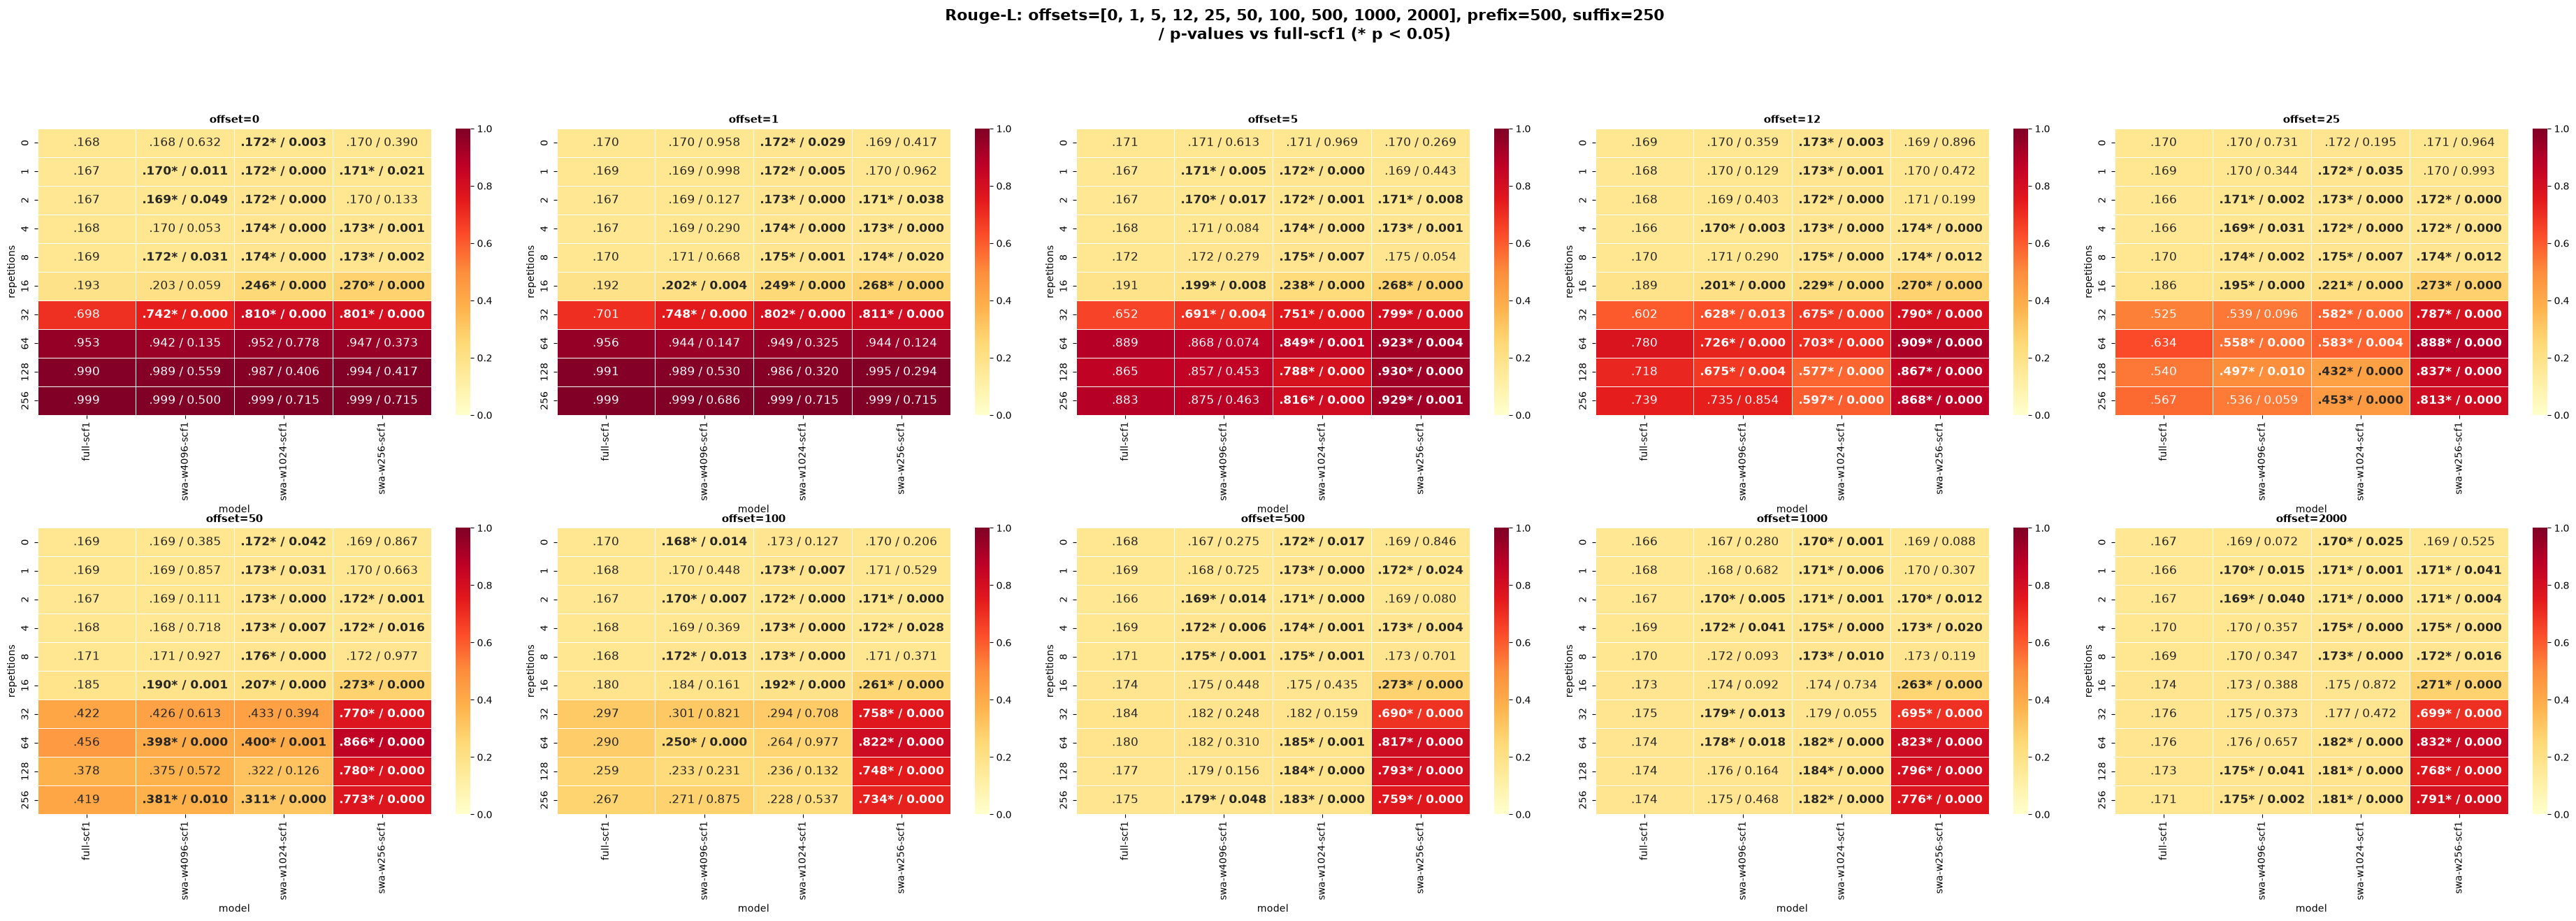

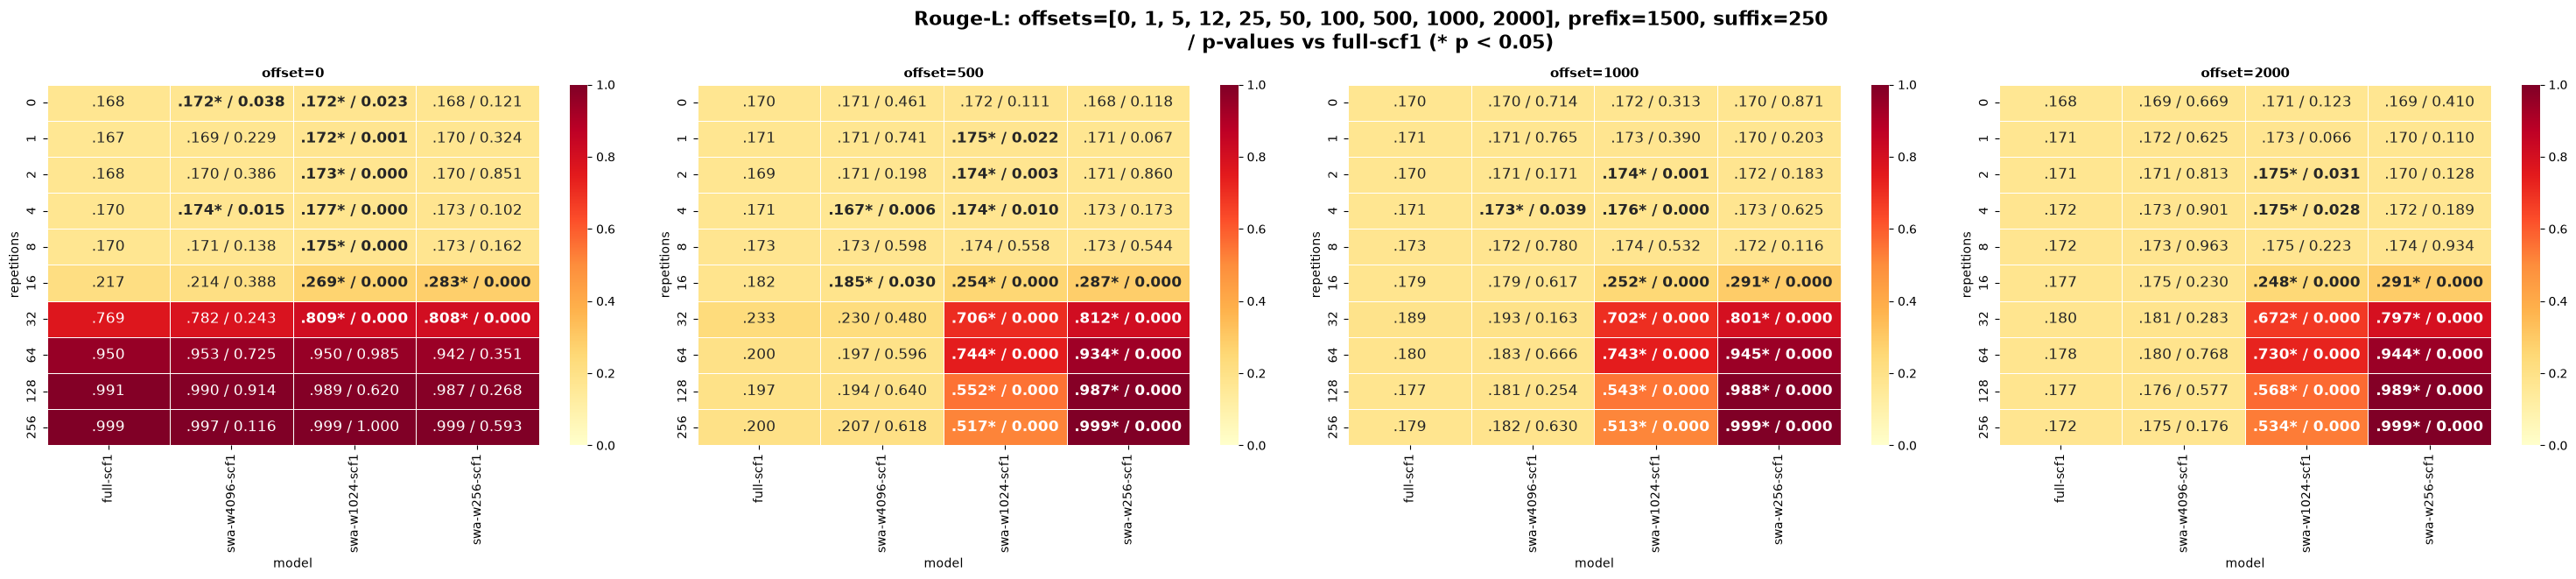

In [4]:
plot_models_heatmap_panel(
    swa_results_grid, 'Rouge-L', panels='offset', values=SWA_OFFSETS, fixed_prefix=500, fixed_suffix=250,
    reference='full-scf1', models=SWA_MODELS, ncols=5
)
plot_models_heatmap_panel(
    swa_results_grid, 'Rouge-L', panels='offset', values=SWA_OFFSETS, fixed_prefix=1500, fixed_suffix=250,
    reference='full-scf1', models=SWA_MODELS, ncols=5
)


## Full vs. SWA window size, across prefixes

Same four models, now sweeping prefix (anchor length) at fixed offset=0, suffix=500 --
the orthogonal axis to the offset panel above. Only prefix=500 has Megatron-backend data
(it's the same baseline point the offset panel above uses); every other prefix here only
exists via HF -- `BACKEND` falls back to it automatically (see title cell).


In [5]:
PREFIXES = [50, 100, 250, 500, 1000, 1500, 2000, 3000, 4000, 5000]

swa_prefix_grid = load_mem_results_scores_grid(
    offsets=[0], prefixes=PREFIXES, suffixes=[250, 500], models=SWA_MODELS, results_base=model_registry.MEM_RESULTS_DIR,
    backend=BACKEND,
)


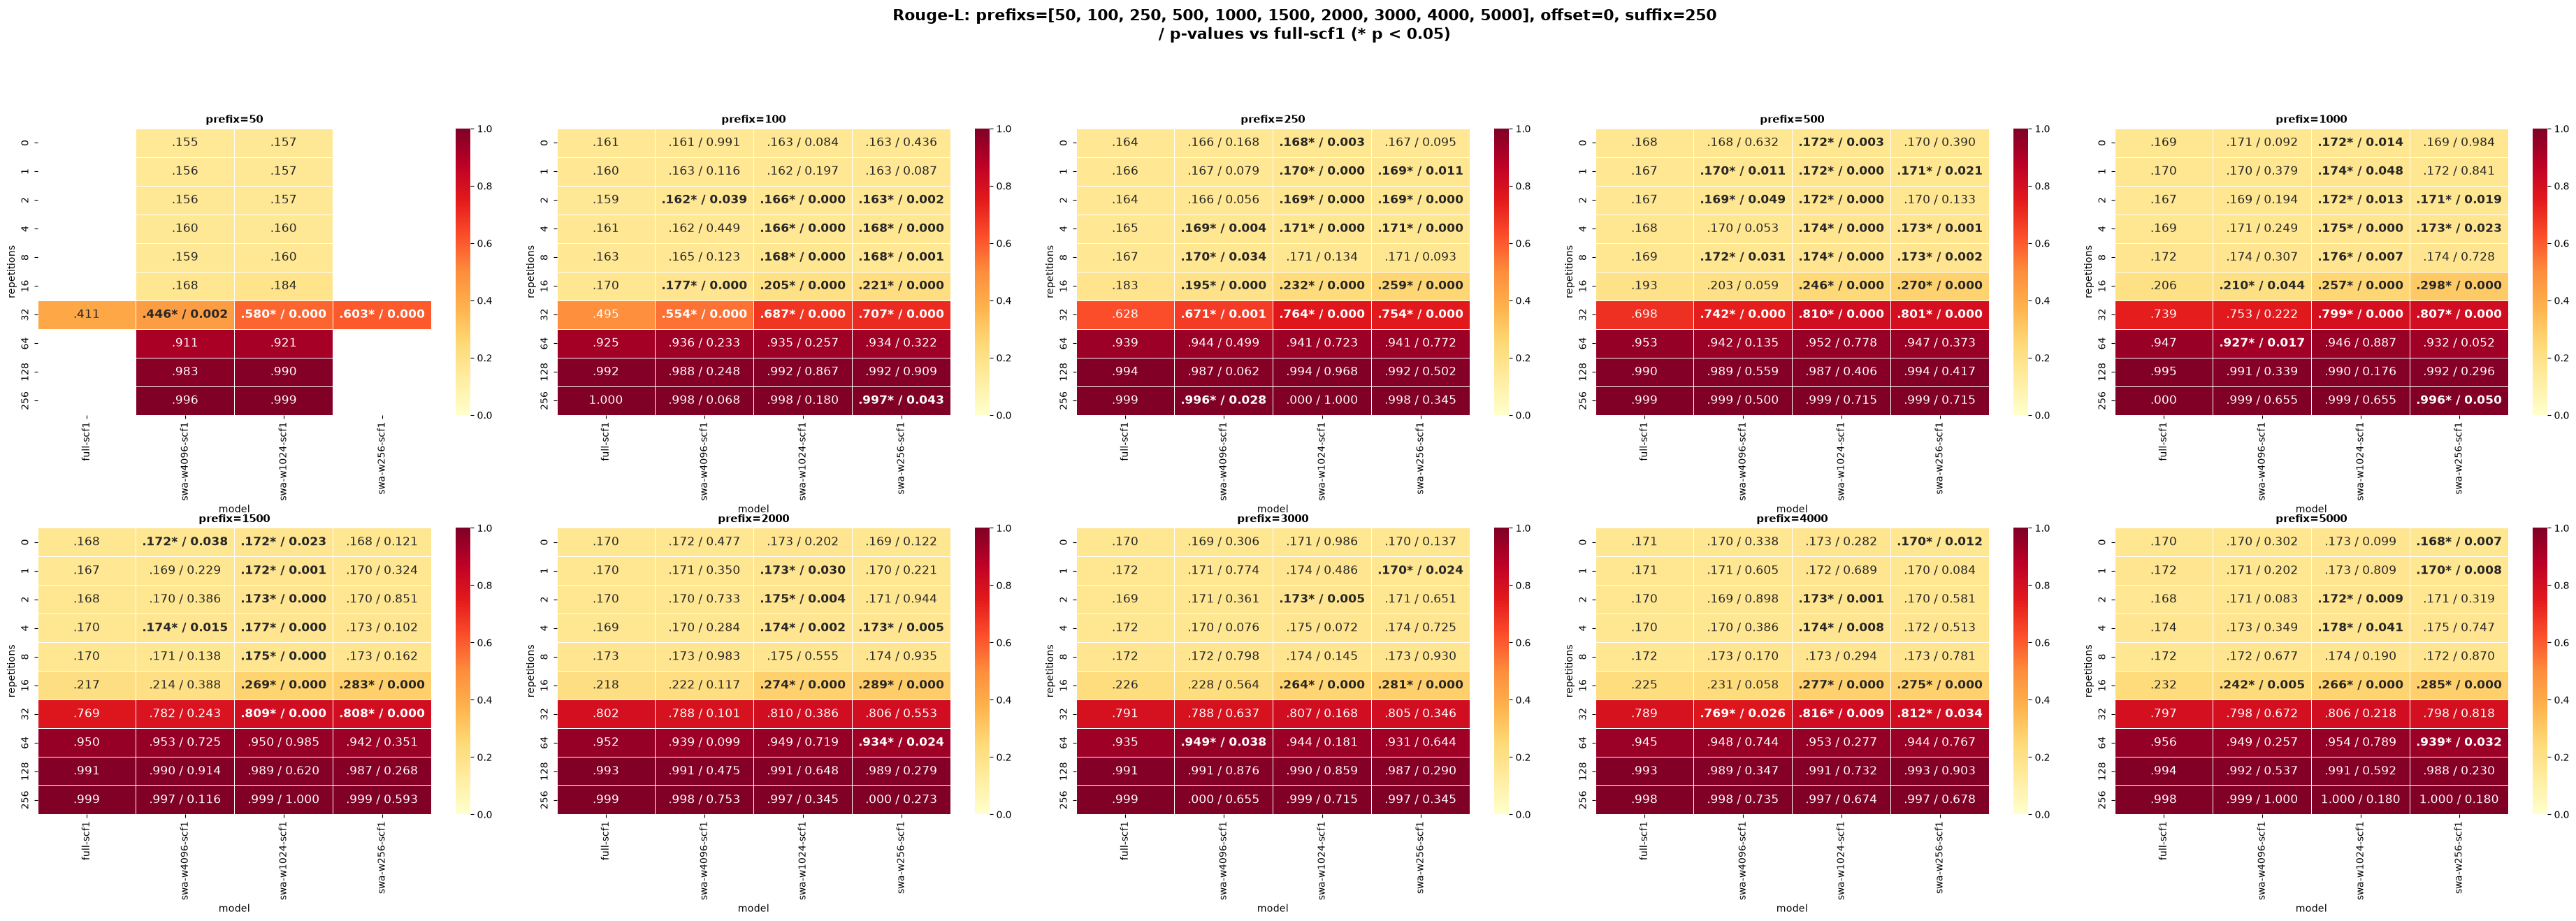

In [6]:
plot_models_heatmap_panel(
    swa_prefix_grid, 'Rouge-L', panels='prefix', values=PREFIXES, fixed_offset=0, fixed_suffix=250,
    reference='full-scf1', models=SWA_MODELS, ncols=5
)



## Full vs. SWA window size, anti-diagonal (fixed suffix_start=1000)

Disentangling prefix (anchor length) from offset (discarded run-up depth), holding
`suffix_start = offset + prefix = 1000` fixed -- same target tokens scored throughout,
only how much of the run-up is a verbatim anchor vs. discarded cold-start context changes.
See `project_mem_offset_prefix_disentangle` for the full rationale. HF-backend data
(via the same `BACKEND` fallback), same `SWA_MODELS` as above.

Densified near the two collapse boundaries found in the original 6-point sweep: between
prefix=750 (collapsed) and prefix=1000 (works) for full/w4096/w1024, and between prefix=250
(collapsed) and prefix=500 (works) for w256 -- including prefix=256 exactly, w256's own
window size, the sharpest test of the "prefix >= window" hypothesis.


In [7]:
SWA_DIAGONAL = [
    (0, 1000), (50, 950), (100, 900), (150, 850), (200, 800), (250, 750),
    (500, 500), (550, 450), (600, 400), (650, 350), (700, 300), (744, 256), (750, 250),
    (900, 100), (950, 50),
]

swa_diagonal_grid = load_mem_results_scores_grid(
    offsets=sorted({o for o, p in SWA_DIAGONAL}), prefixes=sorted({p for o, p in SWA_DIAGONAL}), suffixes=[250, 500],
    models=SWA_MODELS, results_base=model_registry.MEM_RESULTS_DIR, backend=BACKEND,
)


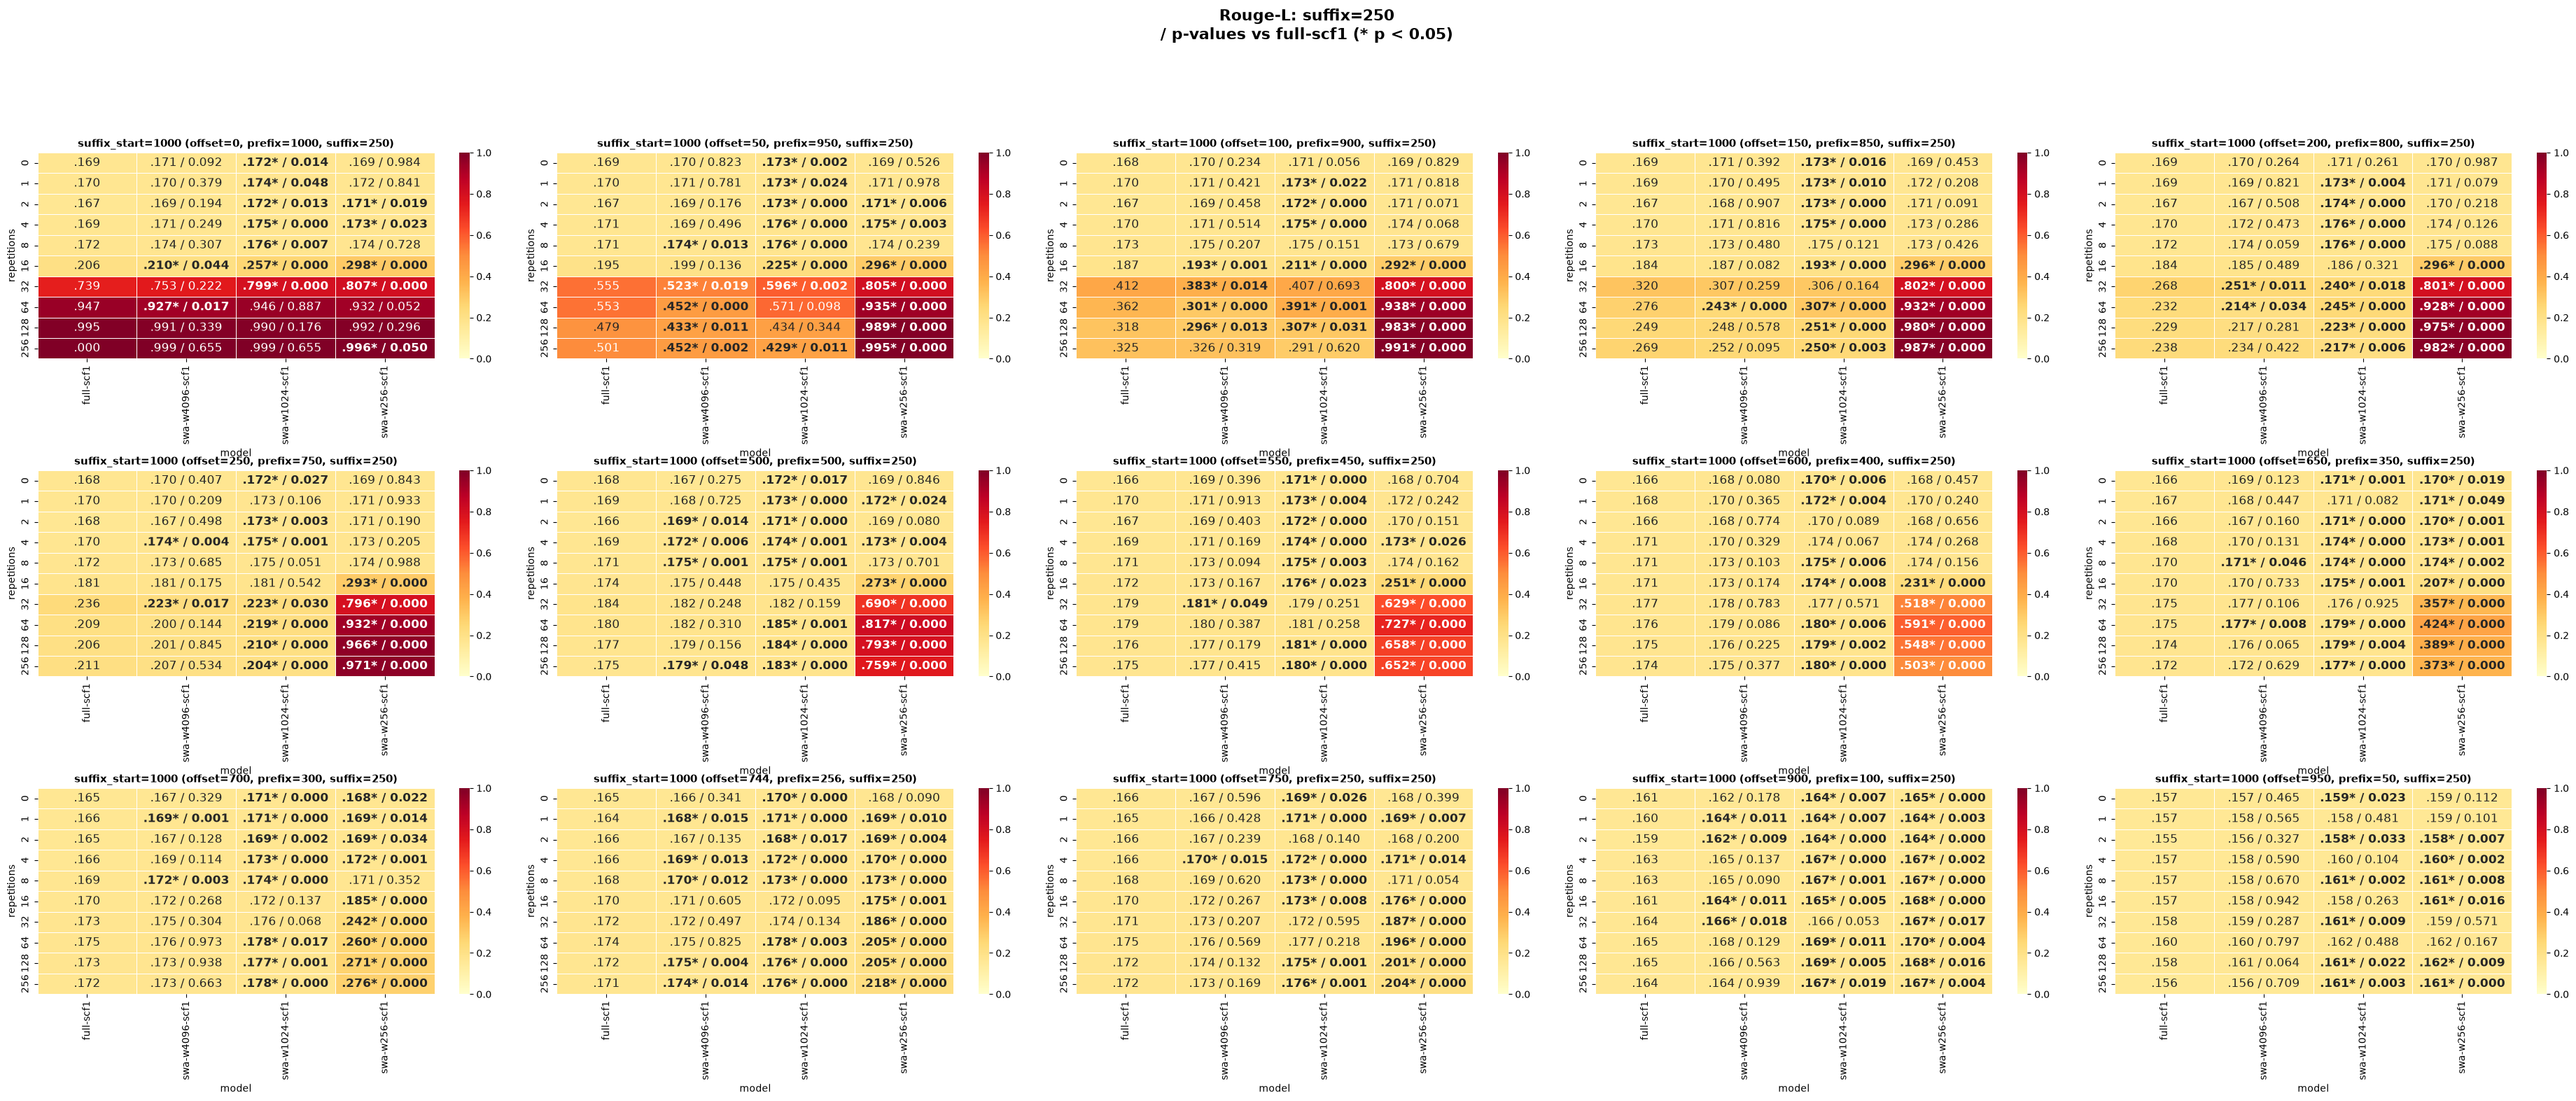

In [8]:
plot_models_heatmap_panel(
    swa_diagonal_grid, 'Rouge-L', panels='diagonal', values=SWA_DIAGONAL, fixed_suffix=250,
    reference='full-scf1', models=SWA_MODELS, ncols=5
)


## Full vs. SWA window size, full offset x prefix grid at suffix=250

Every (offset, prefix) point any model has data for at suffix=250, discovered off disk
rather than hand-listed -- `discover_offset_prefix_points` unions each model's `metrics/`
dir across backends, `load_mem_results_scores_grid`'s own `backend=['hf', 'megatron']`
fallback then sources each cell HF-first, Megatron only where HF has no file. Same four
models as the sections above, now including the fresh `suffix=250` sweep.

In [9]:
GRID_SUFFIX = 250
GRID_MODELS = ['full-scf1', 'swa-w4096-scf1', 'swa-w1024-scf1', 'swa-w256-scf1']

grid_points = discover_offset_prefix_points(GRID_MODELS, GRID_SUFFIX, results_base=model_registry.MEM_RESULTS_DIR)
GRID_OFFSETS = sorted({o for o, p in grid_points})
GRID_PREFIXES = sorted({p for o, p in grid_points})

grid_results = load_mem_results_scores_grid(
    GRID_OFFSETS, GRID_PREFIXES, [GRID_SUFFIX], models=GRID_MODELS,
    results_base=model_registry.MEM_RESULTS_DIR, backend=['hf', 'megatron'],
)

The full 2D grid: one panel per (offset, prefix) point that any model has at
suffix=250 -- this pulls in every suffix=250 point ever computed for these four models, not
just the fresh offset/prefix sweep (including the earlier anti-diagonal and prefix-sweep
points above), so coverage is irregular rather than a clean rectangle.

/Users/Elena.Lyulina/PycharmProjects/swiss-ai/Megatron-LM-Attention-Benchmark/attn_bench/notebooks/../../attn_bench/plotting/utils.py:161: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


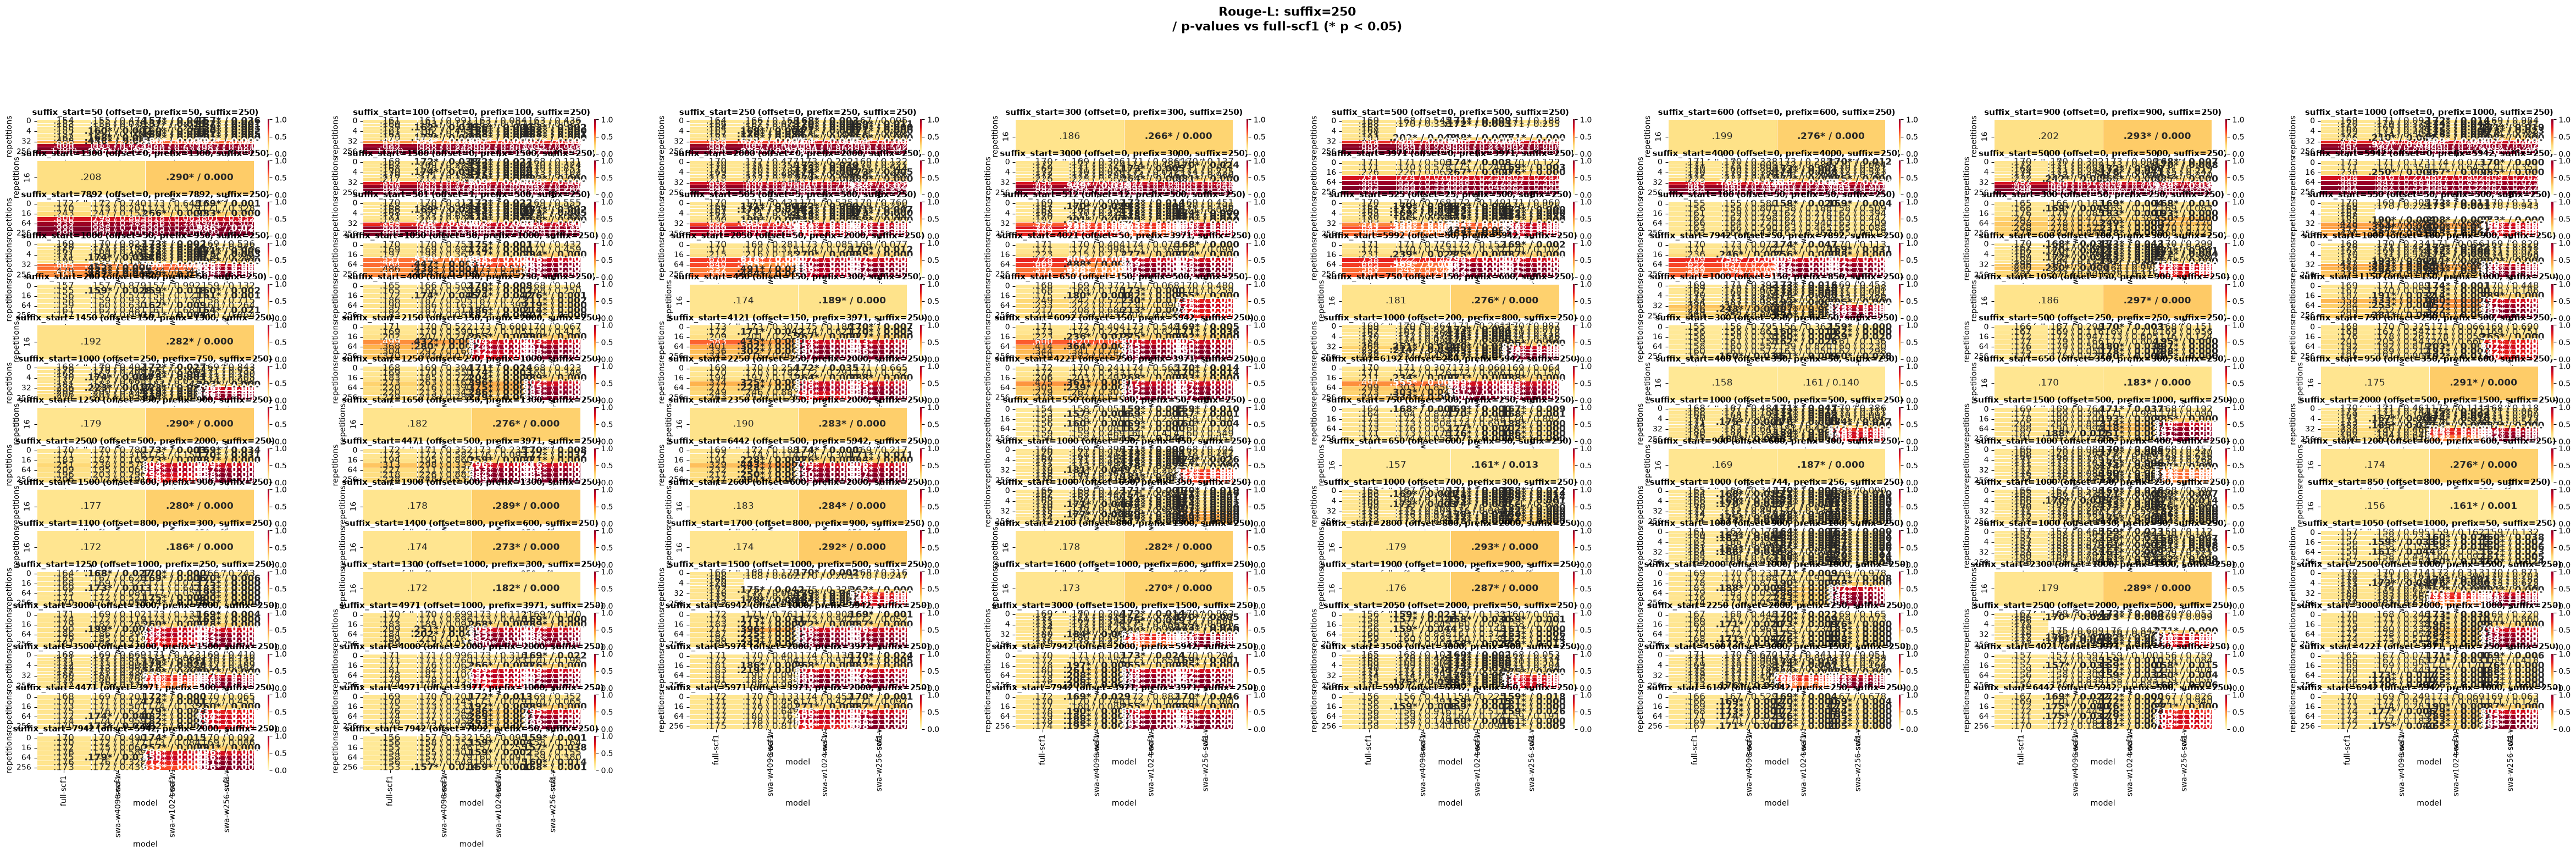

In [11]:
plot_models_heatmap_panel(
    grid_results, 'Rouge-L', panels='diagonal', values=grid_points, fixed_suffix=GRID_SUFFIX,
    reference='full-scf1', models=GRID_MODELS, ncols=8
)
